# Compare Original And Cropped Images

This notebook compares original EMBED images and cropped EMBED images for one patient.

For each image filename belonging to the selected patient, the notebook shows:
- the original image on the left
- the cropped image on the right

## Imports

Load the libraries needed for reading images, normalizing them for display, and plotting the comparisons.

In [11]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

## Configuration

Set the patient ID here before running the notebook. The notebook searches across the `train`, `val`, and `test` folders.

In [12]:
ORIGINAL_ROOT = Path("/mnt/cv_data/users/mengxu/EMBED_Dataset_Split_Uniform_Orientation")
CROPPED_ROOT = Path("/mnt/cv_data/users/mengxu/EMBED_Split_Cropped_PNG_Uniform_Orientation")
SPLITS = ("train", "val", "test")

PATIENT_ID = "10093833"

## Helper Functions

These functions do four things:
- load each image as grayscale
- normalize image intensities for display in matplotlib
- recover the patient ID from the filename
- collect matched original and cropped image pairs

In [13]:
def load_grayscale_image(image_path):
    image = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    return image


def normalize_for_display(image):
    # Normalize each image independently so it displays clearly.
    image = image.astype(np.float32)
    min_value = float(image.min())
    max_value = float(image.max())

    if max_value <= min_value:
        return np.zeros(image.shape, dtype=np.uint8)

    normalized = (image - min_value) / (max_value - min_value)
    return (normalized * 255).astype(np.uint8)


def normalize_patient_id(patient_id):
    patient_id = str(patient_id).strip()
    if patient_id.endswith(".0"):
        patient_id = patient_id[:-2]
    return patient_id


def extract_patient_id_from_filename(image_path):
    # The filename starts with patient_id before the first underscore.
    return normalize_patient_id(image_path.stem.split("_", 1)[0])


def collect_patient_pairs(patient_id, original_root, cropped_root):
    patient_id = normalize_patient_id(patient_id)
    pairs = []

    for split_name in SPLITS:
        split_original_dir = original_root / split_name
        split_cropped_dir = cropped_root / split_name

        if not split_original_dir.exists():
            continue

        for original_path in sorted(split_original_dir.rglob("*.png")):
            if extract_patient_id_from_filename(original_path) != patient_id:
                continue

            cropped_path = split_cropped_dir / original_path.name
            pairs.append(
                {
                    "split": split_name,
                    "filename": original_path.name,
                    "original_path": original_path,
                    "cropped_path": cropped_path if cropped_path.exists() else None,
                }
            )

    return pairs


def collect_available_patient_ids(original_root, limit=10):
    patient_ids = set()

    for split_name in SPLITS:
        split_original_dir = original_root / split_name
        if not split_original_dir.exists():
            continue

        for original_path in split_original_dir.rglob("*.png"):
            patient_ids.add(extract_patient_id_from_filename(original_path))

    return sorted(patient_ids)[:limit]

## Collect Matching Files

This cell finds all original images for the selected patient and checks whether a cropped image with the same filename exists.

In [14]:
patient_id = normalize_patient_id(PATIENT_ID)
pairs = collect_patient_pairs(patient_id, ORIGINAL_ROOT, CROPPED_ROOT)

if not pairs:
    sample_patient_ids = collect_available_patient_ids(ORIGINAL_ROOT)
    sample_text = ", ".join(sample_patient_ids) if sample_patient_ids else "none found"
    raise FileNotFoundError(
        f"No original PNG images found for patient {patient_id} under {ORIGINAL_ROOT}. "
        f"Sample patient IDs: {sample_text}"
    )

print(f"Found {len(pairs)} image pair entries for patient {patient_id}.")
for pair in pairs:
    print(f"[{pair['split']}] {pair['filename']}")

Found 24 image pair entries for patient 10093833.
[test] 10093833_L_CC_2013-06-21_4505_neg_nocancer.png
[test] 10093833_L_CC_2014-07-02_7609_neg_nocancer.png
[test] 10093833_L_CC_2015-07-24_2861_neg_nocancer.png
[test] 10093833_L_CC_2016-07-27_7278_neg_nocancer.png
[test] 10093833_L_CC_2017-08-03_9986_neg_nocancer.png
[test] 10093833_L_CC_2018-09-06_0134_neg_nocancer.png
[test] 10093833_L_MLO_2013-06-21_3665_neg_nocancer.png
[test] 10093833_L_MLO_2014-07-02_3018_neg_nocancer.png
[test] 10093833_L_MLO_2015-07-24_4303_neg_nocancer.png
[test] 10093833_L_MLO_2016-07-27_7700_neg_nocancer.png
[test] 10093833_L_MLO_2017-08-03_5642_neg_nocancer.png
[test] 10093833_L_MLO_2018-09-06_9793_neg_nocancer.png
[test] 10093833_R_CC_2013-06-21_5646_neg_nocancer.png
[test] 10093833_R_CC_2014-07-02_7821_neg_nocancer.png
[test] 10093833_R_CC_2015-07-24_6728_neg_nocancer.png
[test] 10093833_R_CC_2016-07-27_7258_neg_nocancer.png
[test] 10093833_R_CC_2017-08-03_4508_neg_nocancer.png
[test] 10093833_R_CC_2018-

## Display Comparison

Run the cell below to visualize all matched image pairs.

Each row corresponds to one filename:
- left: original image
- right: cropped image

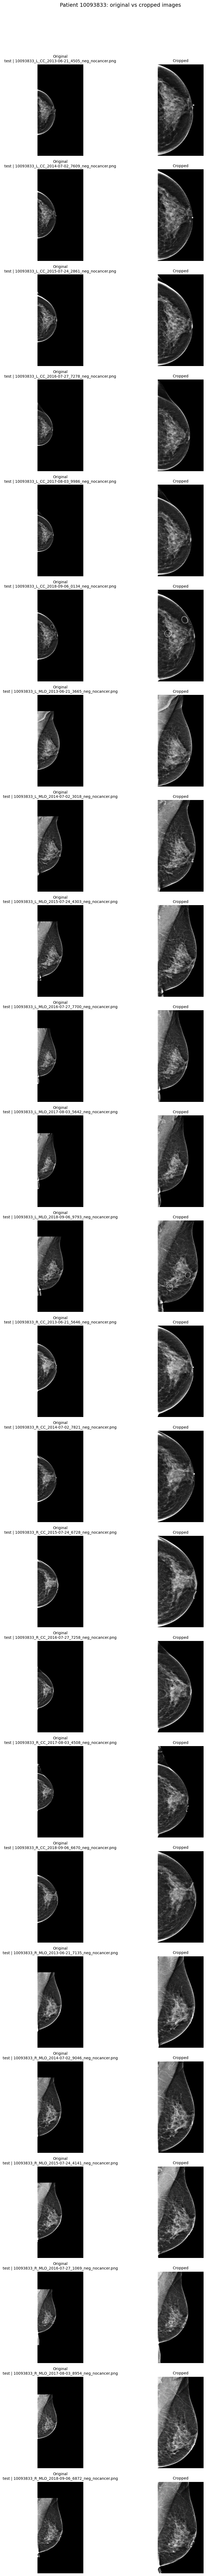

In [15]:
num_rows = len(pairs)
figure, axes = plt.subplots(
    num_rows,
    2,
    figsize=(12, max(4, 4 * num_rows)),
    squeeze=False,
)

figure.suptitle(
    f"Patient {patient_id}: original vs cropped images",
    fontsize=14,
    y=0.995,
)

for row_index, pair in enumerate(pairs):
    original_axis, cropped_axis = axes[row_index]

    original_image = load_grayscale_image(pair["original_path"])
    original_axis.imshow(normalize_for_display(original_image), cmap="gray")
    original_axis.set_title(
        f"Original\n{pair['split']} | {pair['filename']}",
        fontsize=10,
    )
    original_axis.axis("off")

    if pair["cropped_path"] is not None:
        cropped_image = load_grayscale_image(pair["cropped_path"])
        cropped_axis.imshow(normalize_for_display(cropped_image), cmap="gray")
        cropped_axis.set_title("Cropped", fontsize=10)
    else:
        cropped_axis.text(
            0.5,
            0.5,
            "Missing cropped image",
            ha="center",
            va="center",
            fontsize=11,
        )
        cropped_axis.set_title("Cropped", fontsize=10)

    cropped_axis.axis("off")

figure.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()